<a href="https://colab.research.google.com/github/hanbiphyun/ESSA_YB/blob/main/ESAA_OB_week1_1_%ED%95%84%EC%82%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##파이썬 머신러닝 완벽가이드
p488-508


#CH08. 텍스트 분석
- 기존에는 텍스트를 구성하는 언어적인 룰이나 업무의 룰에 따라 분석하는 룰 기반 시스템 -> 머신러닝 분석 기반으로 변경
- NLP (National Language Processing) : 머신이 인간의 언어를 이해하고 해석 중점
  - 예시 : 기계번역, 질의응답 시스템
  - 텍스트 분석을 향상하게 하는 기반 기술
- 텍스트 마이닝(분석) : 비정형 텍스트에서 의미있는 정보 추출 중점
  - 예시 : 비즈니스 인텔리전스, 예측 분석
  - 텍스트 분류 : 문서가 특정 분류 또는 카테고리에 속하는 것 예측함 (신문 기사 내용의 카테고리 분류, 스팸 메일 검출), 지도 학습
  - 감성 분석 : 텍스트 속 주관적 요소 분석함 (소셜 미디어, 영화나 제품에 대한 리뷰, 여론조사 등), 지도+비지도
  - 텍스트 요약 : 텍스트 내 주요 주제나 중심 사상 추출 (토픽 모델링)
  - 텍스트 군집화와 유사도 측정

##**텍스트 분석 이해**

### 배경
1. 머신러닝 알고리즘은 숫자형의 피처 기반인 데이터만 입력받음
2. 그래서 비정형 텍스트를 피처 형태로 추출하고 의미있는 값 부여함
3. 피처에 숫자 값 부여하면 단어의 조합인 벡터값으로 표현됨 = 피처 벡터화, 피처 추출
- BOW / Word2Vec

###**텍스트 분석 수행 프로세스**
1. 텍스트 사전 준비작업(전처리) - 대/소문자 변경, 특수문자 삭제 (클렌징 작업), 단어 등의 토큰화 작업, 어근 추출
2. 피처 벡터화/추출 : 텍스트에서 피처 추출하고 벡터값 할당 - BOW (Count 기반& TF-IDF 기반 벡터화), Word2Vec
3. ML 모델 수립 및 학습/예측/평가 : 데이터에 ML모델을 적용
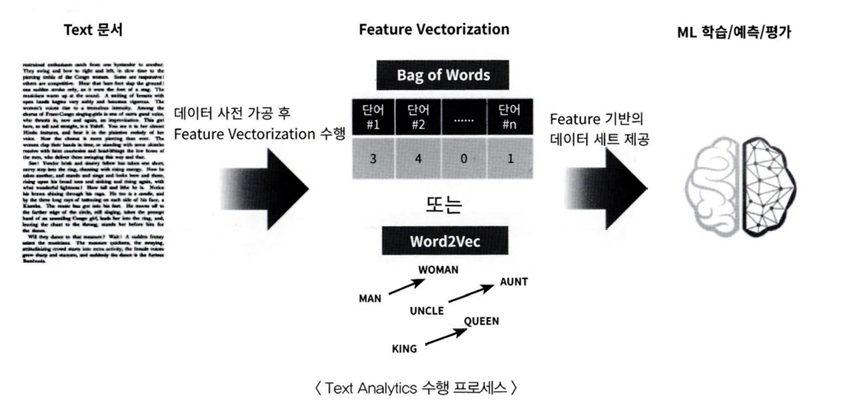

### **파이썬 기반의 NLP, 텍스트 분석 패키지**
1. NLTK (Natural Language Toolkit for Python) : 텍스트 전처리의 모든 것, 속도가 느리고 전통적인 기법
2. Gensim : 토픽 모델링과 단어 유사도에 특화됨, 단어 간의 연산 가능하게 하는 벡터화 역할 => 대용량 텍스트 처리에 효율적
3. SciPy : 벡터화된 텍스트의 수학적 계산(희소 행렬 처리- 유사도 계산)


##**02. 텍스트 사전 준비 작업(텍스트 전처리) - 텍스트 정규화**

**클렌징**
: 방해되는 불필요한 문자, 기호 등 사전 제거 ex) HTML, XML 태그나 특정 기호

**문장 토큰화**
: 문장의 마침표, 행바꿈 문자 등의 기호에 따라 분리함

-> NTLK에서 많이 쓰이는 sent_tokenize 이용해 수행 실습


In [1]:
# 3개의 문장으로 이루어진 텍스트 문서 분리
from nltk import sent_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

text_sample= 'The Matrix is everywhere its all round us, here even in this room. \
You can see it out your window or on your television. \
You feel it when you go to work, or go to church or pay your taxes'
sentences = sent_tokenize(text=text_sample)
print(type(sentences), len(sentences))
print(sentences)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


<class 'list'> 3
['The Matrix is everywhere its all round us, here even in this room.', 'You can see it out your window or on your television.', 'You feel it when you go to work, or go to church or pay your taxes']


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [2]:
# 단어토큰화
from nltk import word_tokenize

sentence= 'The Matrix is everywhere its all around us, here even in this room.'
words = word_tokenize(sentence)
print(type(words), len(words))
print(words)

<class 'list'> 15
['The', 'Matrix', 'is', 'everywhere', 'its', 'all', 'around', 'us', ',', 'here', 'even', 'in', 'this', 'room', '.']


sent_tokenize & word_tokenize 조합해서 모든 단어 토큰화하기

In [3]:
from nltk import word_tokenize

# 여러 개의 문장으로 된 입력 데이터를 문장별로 단어 토큰화하게 만드는 함수 생성
def tokenize_text(text):

    # 문장별로 분리 토큰
    sentences = sent_tokenize(text)
    # 분리된 문장별 단어 토큰화
    word_tokens= [word_tokenize(sentence) for sentence in sentences]
    return word_tokens

# 여러 문장에 대해 문장별 단어 토큰화 수행
word_tokens= tokenize_text(text_sample)
print(type(word_tokens), len(word_tokens))
print(word_tokens)

<class 'list'> 3
[['The', 'Matrix', 'is', 'everywhere', 'its', 'all', 'round', 'us', ',', 'here', 'even', 'in', 'this', 'room', '.'], ['You', 'can', 'see', 'it', 'out', 'your', 'window', 'or', 'on', 'your', 'television', '.'], ['You', 'feel', 'it', 'when', 'you', 'go', 'to', 'work', ',', 'or', 'go', 'to', 'church', 'or', 'pay', 'your', 'taxes']]


- 문장을 단어별로 하나씩 토큰화하여 문맥적 의미 무시됨-> n-gram으로 해결시도 (연속된 n개의 단어를 하나의 토큰화 단위로 분리함)

-> 나는 어제 밥을 먹었다 -> 나는 어제 / 어제 밥을 / 밥을 먹었다

**스톱 워드 제거**
: 스톱 워드는 분석에 의미 없는 단어임

In [4]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
print('영어 stop words 개수:', len(nltk.corpus.stopwords.words('english')))
print(nltk.corpus.stopwords.words('english')[:20])

영어 stop words 개수: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


In [6]:
# stopwords 필터링해서 의미있는 단어만 추출
import nltk

stopwords = nltk.corpus.stopwords.words('english')
all_tokens= []
# 위 예제에서 3개의 문장별로 얻은 word_tokens list에 대해 스톱워드를 제거하는 반복문
for sentence in word_tokens:
    filtered_words=[]
    # 개별 문장별로 토큰화된 문장 list에 대해 스톱 워드를 제거하는 반복문
    for word in sentence:
        # 소문자로 모두 변환합니다.
        word= word.lower()
        # 토큰화된 개별 단어가 스톱 워드의 단어에 포함되지 않으면 word_tokens에 추가
        if word not in stopwords:
            filtered_words.append(word)

    all_tokens.append(filtered_words)

print(all_tokens)

[['matrix', 'everywhere', 'round', 'us', ',', 'even', 'room', '.'], ['see', 'window', 'television', '.'], ['feel', 'go', 'work', ',', 'go', 'church', 'pay', 'taxes']]


**Stemming & Lemmatization**
: 문법적 또는 의미적으로 변화하는 단어의 원형 찾기
- Stemming : 원래 단어에서 일부 철자가 훼손된 어근단어 추출
- Lemmatization :원형 단어로 변환에 더 긴 시간을 필요로 함

- NLTK 의 Stemmer - Porter, Lancaster, Snowball Stemmer, WordNetLemmatizer( for Lemmatization)

-> LancasterStemmer 를 이용해 Stemmer 객체 생성한 뒤 이 객체의 stem('단어') 메서드 호출 시 원하는 '단어'의 Stemming 가능

In [7]:
from nltk.stem import LancasterStemmer
stemmer = LancasterStemmer()

print(stemmer.stem('working'), stemmer.stem('works'), stemmer.stem('worked'))
print(stemmer.stem('amusing'), stemmer.stem('amuses'), stemmer.stem('amused'))
print(stemmer.stem('happier'), stemmer.stem('happiest'))
print(stemmer.stem('fancier'), stemmer.stem('fanciest'))

work work work
amus amus amus
happy happiest
fant fanciest


- 단순 변화는 원형 단어 제대로 인식하지만 아닌 경우나 비교급 형태는 잘 인식하지 못함
- WordNetLemmatizer를 이용해 Lemmatization수행 : 단어의 품사 입력해줘야함

In [8]:
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')

lemma = WordNetLemmatizer()
print(lemma.lemmatize('amusing', 'v'), lemma.lemmatize('amuses', 'v'), lemma.lemmatize('amused', 'v'))
print(lemma.lemmatize('happier', 'a'), lemma.lemmatize('happiest', 'a'))
print(lemma.lemmatize('fancier', 'a'), lemma.lemmatize('fanciest', 'a'))

[nltk_data] Downloading package wordnet to /root/nltk_data...


amuse amuse amuse
happy happy
fancy fancy


##03. Bag of Words - BOW
: 문서가 갖는 모든 단어를 문맥이나 순서를 무시하고 일괄적으로 빈도 값을 부여해서 피처 값 추출함
- 문장 속 단어 개수 기재
- 장점 : 쉽고 빠른 구축
- 단점 : 문맥 의미 반영 부족, 희소 행렬 문제

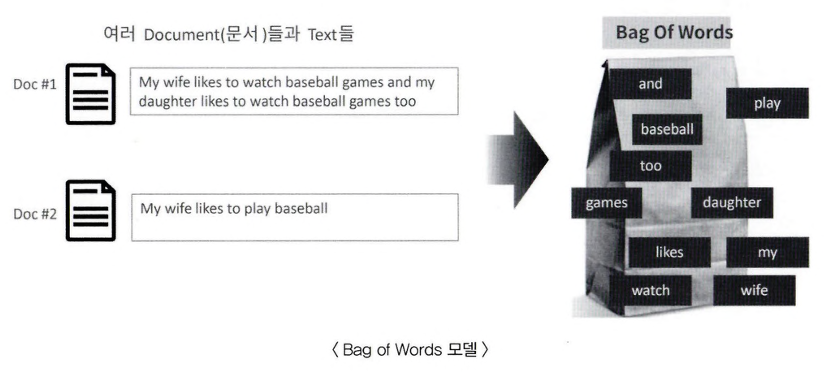

**BOW 피처 벡터화**
- 넓은 범위의 피처 추출
- 모든 단어를 칼럼 형태로 나열하고 각 문서에서 해당 단어의 횟수나 정규화된 빈도를 값으로 부여하는 데이터 세트 모델로 변경하는 것

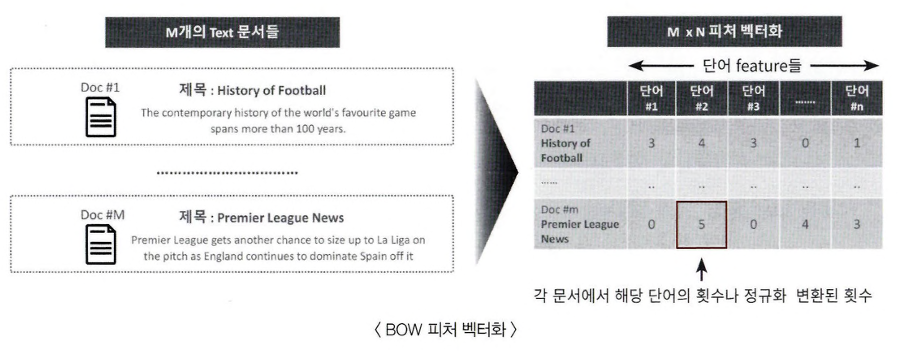

- 방식 : 카운트 기반, TF-IDF
  - 텍스트 길고 문서개수 많은 경우 TF-IDF 방식 유용
  


- BOW의 TF-IDF 방식
: 빈도수 높은 단어에 가중치부여, 모든 문서에 자주 나타나는 단어에는 패널티 부여

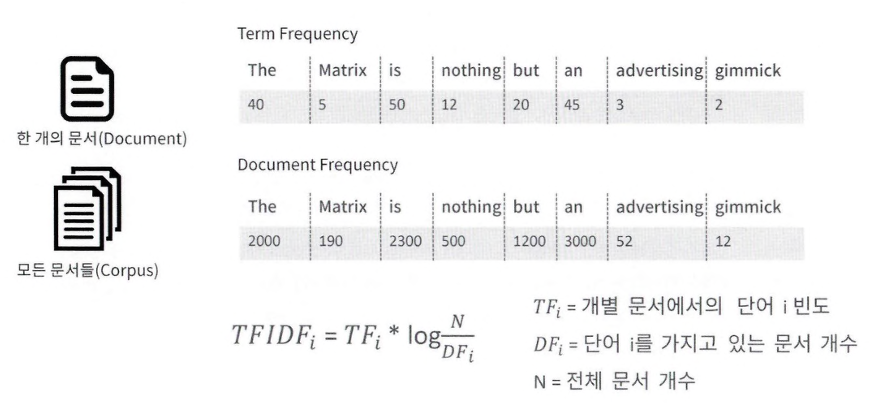



**사이킷런의 Count 및 TF-IDF 벡터화 구현: CountVectorizer, TfidVectorizer**
- CountVectorizer 클래스 : 카운트 기반의 벡터화 구현, 소문자 일괄 변환, 토큰화, 스톱 워드 필터링 등의 텍스트 전처리
  - fit(), transform()을 통해 피처 벡터화된 객체 반환
- 입력 파라미터
    - max_df (높은 빈도수 갖는 단어 제외)
    - min_df (낮은 빈도수 갖는 단어 제외)
    - max_features (추출 피처 개수 제한)
    - stop_words
    - n_gram_range (BOW 모델의 단어 순서 보강)
    - analyzer (피처 추출 수행 단위를 지정함)
    - tokenizer
- 피처 벡터화 방법
1. (영어) 모든 문자를 소문자로 변경하는 등 전처리
2. 디폴트로 단어를 기준으로 n_gram_range 반영해 단어를 토큰화
3. 텍스트 정규화 수행
4. 파라미터 이용해 단어를 피처로 추출하고 단어 빈도수 벡터값을 적용함

+ TF-IDF : TfidVorizer 클래스 이용

**BOW 벡터화를 위한 희소 행렬**
- 희소 행렬은 불필요한 0 값이 메모리 할당되고, 연산에 시간도 많이 소모되는 문제가 있음
- 해결 1. COO (Coordinate) : 0이 아닌 데이터만 별도의 데이터 배열에 저장하고, 데이터가 가리키는 행.열의 위치를 따로 배열로 저장함
    - Scipy 이용

- 해결 2. CSR (Compressed Sparse Row) 형식 : COO의 반복적인 위치 데이터 사용하는 문제를 해결함
  - 위치의 위치를 표기하는 방식 + 데이터의 총 항목 개수 추가
  - 메모리가 적고 빠른 연산 가능

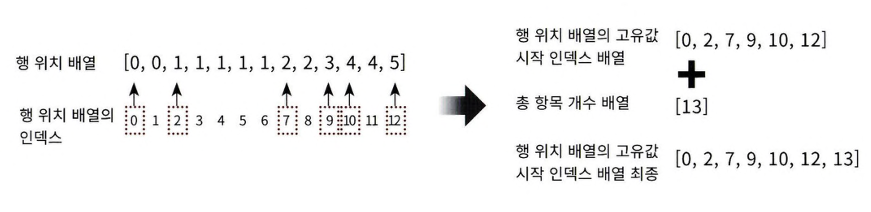


In [9]:
import numpy as np
dense= np.array([[3,0,1],[0,2,0]])

In [10]:
# Scipy의 coo_matrix클래스 이용해 COO형식의 희소행렬로 변환
from scipy import sparse

#0이 아닌 데이터 추출
data=np.array([3,1,2])

#행 위치와 열 위치를 각각 배열로 생성
row_pos= np.array([0,0,1])
col_pos= np.array([0,2,1])

# sparse 패키지와 coo_matrix를 이용해 COO 형식으로 희소 행렬 생성
sparse_coo= sparse.coo_matrix((data, (row_pos, col_pos)))

- sparse_coo는 COO형식의 희소 행렬 객체 변수
- toarray()이용해 다시 밀집 행렬로 출력

In [11]:
sparse_coo.toarray()

array([[3, 0, 1],
       [0, 2, 0]])

In [13]:
# CSR 방식의 변환 - Scipy 의 csr_matrix 클래스 이용
from scipy import sparse

dense2= np.array([[0,0,1,0,0,5],
                  [1,4,0,3,2,5],
                  [0,6,0,3,0,0],
                  [2,0,0,0,0,0],
                  [0,0,0,7,0,8],
                  [1,0,0,0,0,0]])

# 0이 아닌 데이터 추출
data2= np.array([1,5,1,4,3,2,5,6,3,2,7,8,1])

# 행 위치와 열 위치를 각각 array로 생성
row_pos= np.array([0,0,1,1,1,1,1,2,2,3,4,4,5])
col_pos= np.array([2,5,0,1,3,4,5,1,3,0,3,5,0])

# COO 형식으로 변환
sparse_csr= sparse.csr_matrix((data2, col_pos, row_pos))

print('COO 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인')
print(sparse_coo.toarray())
print('CSR 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인')
print(sparse_csr.toarray())

COO 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인
[[3 0 1]
 [0 2 0]]
CSR 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인
[[0 0 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 5]
 [0 0 0 0 0 0]
 [1 0 0 0 0 0]
 [0 4 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 3 0 0]]


- 실제 사용 시 밀집 행렬을 생성 파라미터로 입력하면 COO / CSR 희소 행렬로 생성함
- 사이킷런의 CountVertorizer / TfidfVectorizer 클래스로 변환된 피처 벡터화 행렬은 모두 CSR 형태의 희소 행렬임

In [14]:
dense3= np.array([[0,0,1,0,0,5],
                  [1,4,0,3,2,5],
                  [0,6,0,3,0,0],
                  [2,0,0,0,0,0],
                  [0,0,0,7,0,8],
                  [1,0,0,0,0,0]])

coo= sparse.coo_matrix(dense3)
csr= sparse.csr_matrix(dense3)